In [1]:
library("SeuratDisk")
library("zellkonverter")
library("Seurat")
library(tidyverse)
library(ComplexHeatmap)
library(tidyverse)
library(devtools)
library(circlize)
library(RColorBrewer)
library(gridExtra)
library(forcats)
library(ggplot2)

Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Registered S3 method overwritten by 'zellkonverter':
  method                                             from      
  py_to_r.pandas.core.arrays.categorical.Categorical reticulate

Lade n"otiges Paket: SeuratObject

Lade n"otiges Paket: sp

'SeuratObject' was built under R 4.4.0 but the current version is
4.4.2; it is recomended that you reinstall 'SeuratObject' as the ABI
for R may have changed


Attache Paket: 'SeuratObject'


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, t


-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.2
v ggplot2   4.0.0     v tibble    3.3.0
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.1.0     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()


In [198]:
dir <- "~/Desktop/PhD/NMC/results"

#read interaction file
interaction_tumor_to <- read.csv(file.path(dir, "Tumor cells_interaction_to.csv"))


In [199]:
#make cells_split factors
cells_split <- c("Myeloid", "Myeloid", "Myeloid", "Myeloid", "Myeloid", "Myeloid", "Myeloid", "Lymphoid", "Lymphoid", "Lymphoid", "Lymphoid", "Lymphoid", "Lymphoid")

cells_split <- factor(cells_split, levels = c("Myeloid", "Lymphoid"))

cell_types <- c(
  "MDSCs", "M2 macrophages", "M1 macrophages", "M1/M2 macrophages",
  "Granulocytes", "Mast cells", "DCs", "B cells", "PCs", "NK cells",
  "Treg T cells", "CD4+ T cells", "CD8+ T cells")

In [116]:
#make cells_split factors
cells_split <- c("Suppressive", "Suppressive", "Effector", "Suppressive/Effector", "Suppressive/Effector", "Suppressive/Effector", "Suppressive/Effector", "Suppressive/Effector", "Effector", "Suppressive", "Effector", "Effector", "Suppressive/Effector")

cells_split <- factor(cells_split, levels = c("Suppressive", "Suppressive/Effector", "Effector"))

cell_types <- c(
  "MDSCs", "M2 macrophages", "M1 macrophages", "M1/M2 macrophages",
  "DCs", "Granulocytes", "B cells", "Mast cells", "CD8+ T cells",
  "Treg T cells", "NK cells", "CD4+ T cells", "PCs"
)

In [200]:
cell_types_order <- paste0(cell_types, "-Tumor cells") 

interaction_tumor_to_mat <- interaction_tumor_to %>%
  select(!cell_category) %>%
  pivot_wider(names_from = "patient_exp", values_from = "zscore") %>%
  arrange(factor(cell_pair, levels = cell_types_order)) %>%
  column_to_rownames(var = "cell_pair") %>%
  as.matrix() %>%
  scale()

interaction_tumor_to_mat

,NMC_1_ROI1,NMC_1_ROI3,NMC_2_ROI1,NMC_4_ROI9,NMC_5_ROI10,NMC_5_ROI11,NMC_6_ROI5,NMC_6_ROI6,NMC_7_ROI14,NMC_7_ROI13,...,NMC_12_ROI5,NMC_13_ROI14,NMC_13_ROI15,NMC_14_ROI8,NMC_14_ROI11,NMC_15_ROI7,NMC_15_ROI16,NMC_16_ROI17,NMC_16_ROI19,NMC_21_ROI23
MDSCs-Tumor cells,0.22809938,0.85765961,1.38104512,1.0614476,1.04221415,1.20738644,NA,NA,0.2403372,1.158811481,...,1.55546938,0.9387256,0.1493563,0.69172228,0.963897608,0.1290210,-0.4539412,1.66058830,-2.04070705,NA
M2 macrophages-Tumor cells,0.06133917,0.81393543,1.42707859,-0.2690206,0.86402684,0.68407942,1.39959512,-1.45349513,-2.1748602,1.760266449,...,0.59245435,-1.0314131,-2.2458015,-0.09629850,0.538888751,-0.1779378,0.2496987,0.68770588,0.98762180,-0.6465230
M1 macrophages-Tumor cells,0.45724611,-0.40812873,-0.11247082,NA,-0.05087537,0.25683336,0.78584078,0.07909911,0.8728425,-0.006425759,...,0.20212553,-0.6260227,-0.3266592,0.54206773,-0.030403332,-1.0804082,0.7051326,0.36352750,-0.33708587,NA
M1/M2 macrophages-Tumor cells,-1.03415517,1.67943193,0.62300213,NA,0.74232578,-0.12561121,-0.31337313,0.04887647,0.1239129,1.105911707,...,0.85929780,-0.6586792,-0.7952696,-0.03093078,1.157024519,0.7059914,1.0680943,0.03059277,0.08315745,-0.6322629
Granulocytes-Tumor cells,NA,NA,0.65738109,0.9219173,0.24806983,-2.82811234,1.24087401,0.76807139,0.1980279,-0.394338247,...,NA,NA,NA,0.25737165,-0.006740445,-1.1085609,-1.1085526,0.09276194,-0.19401705,-1.0574131
Mast cells-Tumor cells,NA,NA,-0.08049204,-0.4838792,-0.01741477,-0.46204899,-0.71833212,NA,0.1382166,-1.086192952,...,NA,NA,NA,0.49015099,0.066181028,-1.5728859,-2.0658063,0.31512291,NA,0.8519855
DCs-Tumor cells,NA,NA,-1.38869354,NA,1.69657064,0.18685305,0.33170547,0.87473163,1.4643609,0.160628556,...,-0.02725542,NA,0.8935076,1.16069274,-0.902739109,NA,NA,0.05492835,0.40724171,-0.0442789
B cells-Tumor cells,0.84836707,NA,NA,NA,-0.68703231,0.09981555,-0.82069356,-0.21960033,0.6128492,0.498341994,...,NA,1.0091262,0.7317559,NA,1.342489865,0.5087860,0.3978616,-2.75456766,NA,NA
PCs-Tumor cells,-2.11495800,-1.64193458,NA,NA,-0.69857368,NA,-1.82068156,-2.22299819,NA,NA,...,-0.35089740,1.2192823,0.4327006,0.48532325,0.334252911,0.1804144,0.8570055,-0.15282040,NA,NA
NK cells-Tumor cells,0.67982692,-0.44058803,0.16636322,-1.5513706,-0.04805001,0.67710283,-0.09219548,0.54776174,NA,-1.246469933,...,-0.26535918,NA,NA,NA,NA,NA,-0.1674618,0.30422109,NA,NA


In [204]:
main_col_fun = colorRamp2(
  c(-1.5,0,1.5), 
  c("#0055FF", "#f7f7f7", "#FF0000FF"))



ht = Heatmap(interaction_tumor_to_mat,
        column_names_rot = 45,
        row_split = cells_split,
        col = main_col_fun,
        border = TRUE,
        heatmap_legend_param = list(title = "Interaction score (zscore)",
        title_gp = gpar(fontsize = 16),
        labels_gp = gpar(fontsize = 13),
        legend_height = unit(3, "cm"),
        legend_width  = unit(3, "cm")),
        cluster_rows  = FALSE,
        cluster_columns = FALSE,
        column_title = "Preference interaction scores to Tumor cells",
        row_title = "Cell Pairs",
        row_names_side = "left",
        column_names_gp = gpar(fontsize = 13),
        row_names_gp = gpar(fontsize = 13),
        column_title_gp = gpar(fontsize = 20),
        row_title_gp = gpar(fontsize = 20)
)


ht

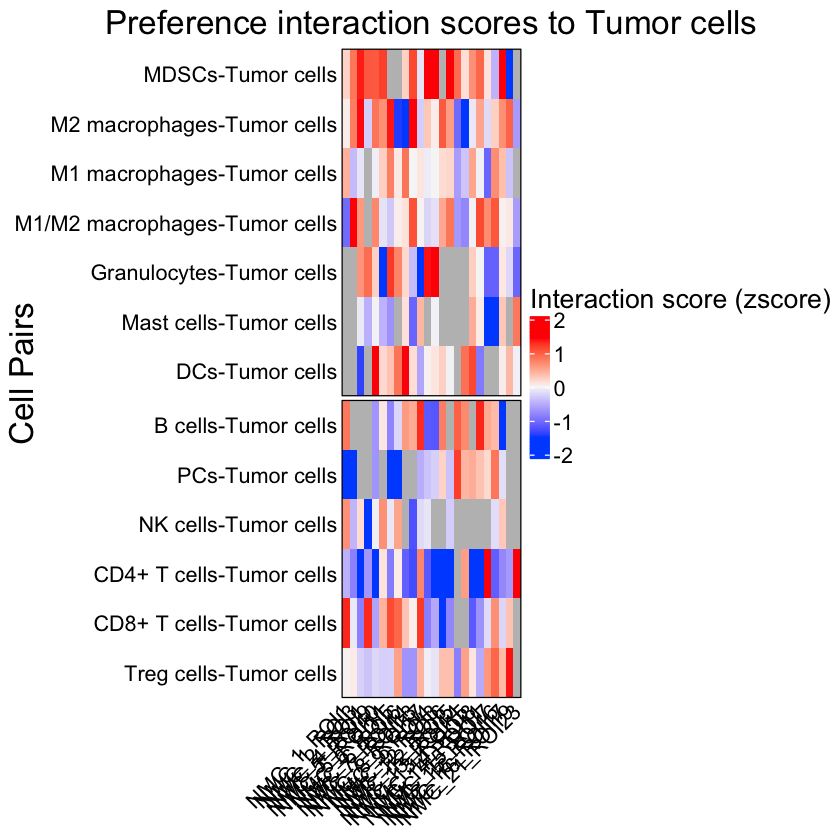

In [205]:
ht

In [206]:
svglite::svglite(filename = "~/Desktop/PhD/NMC/results/heatmap_output_interaction.svg", width = 12, height = 6)
draw(ht)
dev.off()

agg_record_926920305 
                   2

In [131]:
interaction_tumor_to

patient_exp,cell_pair,zscore,cell_category
<chr>,<chr>,<dbl>,<chr>
NMC_1_ROI1,B cells-Tumor cells,14.5964367,B cells
NMC_1_ROI1,CD4+ T cells-Tumor cells,-18.6492145,CD4+ T cells
NMC_1_ROI1,CD8+ T cells-Tumor cells,26.8037804,CD8+ T cells
NMC_1_ROI1,DCs-Tumor cells,NA,DCs
NMC_1_ROI1,Granulocytes-Tumor cells,NA,Granulocytes
NMC_1_ROI1,M1 macrophages-Tumor cells,4.7879343,M1 macrophages
NMC_1_ROI1,M1/M2 macrophages-Tumor cells,-32.6133158,M1/M2 macrophages
NMC_1_ROI1,M2 macrophages-Tumor cells,-5.1405905,M2 macrophages
NMC_1_ROI1,MDSCs-Tumor cells,-0.9585903,MDSCs


In [143]:
interaction_tumor_to_box <- interaction_tumor_to_mat %>%
  as.data.frame() %>%
  tibble::rownames_to_column("cell_pair") %>%
  pivot_longer(
    cols = -cell_pair,
    names_to = "patient_exp",
    values_to = "zscore"
  )

In [152]:
library(ggpubr)

In [157]:
# Step 1: Get median zscore per cell_pair to order
cell_pair_order <- interaction_tumor_to_box %>%
  group_by(cell_pair) %>%
  summarise(median_z = median(zscore, na.rm = TRUE)) %>%
  arrange(desc(median_z)) %>%
  pull(cell_pair)

# Step 2: Reorder factor levels
interaction_tumor_to_box <- interaction_tumor_to_box %>%
  mutate(cell_pair = factor(cell_pair, levels = cell_pair_order)) 

my_comparisons <- combn(unique(interaction_tumor_to_box$cell_pair), 2, simplify = FALSE)


# Step 3: Plot
a = ggplot(interaction_tumor_to_box, aes(x = cell_pair, y = zscore, fill = cell_pair)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, alpha = 0.5,) +
  labs(
    title = "Immune cells interaction with Tumor_cells",
    x = "Cell Pair",
    y = "Interaction Score"
  ) + 
  stat_compare_means(method = "kruskal.test", label.y = max(interaction_tumor_to_box$zscore, na.rm = TRUE) + 0.3, label.x = 3) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  #hide legend
  theme(legend.position = "none")


In [175]:
cell_category_color = c(
    "B cells-Tumor cells" = "#FFFF00",
    "DCs-Tumor cells" = "#00FF00",
    "Granulocytes-Tumor cells" = "#FF00FF",
    "Mast cells-Tumor cells" = "#AA007F",
    "MDSCs-Tumor cells" = "#00007F",
    "NK cells-Tumor cells" = "#00AAFF",
    "PCs-Tumor cells" = "#FFFF7F",
    "CD4+ T cells-Tumor cells" = "#0055FF",
    "CD8+ T cells-Tumor cells" = "#FF0000FF",
    "Treg cells-Tumor cells" = "#AAFF7F",
    "M1 macrophages-Tumor cells" = "#00557F",
    "M2 macrophages-Tumor cells" = "#00AA7F",
    "M1/M2 macrophages-Tumor cells" = "#007F7F"
)

a <- ggplot(interaction_tumor_to_box, aes(x = cell_pair, y = zscore, fill = cell_pair)) +
  geom_boxplot() +
  geom_jitter(width = 0.2, alpha = 0.5) +
  labs(
    title = "Immune cells interaction with Tumor_cells",
    x = "Cell Pairs",
    y = "Interaction Score"
  ) + 
  stat_compare_means(
    method = "kruskal.test",
    label.y = max(interaction_tumor_to_box$zscore, na.rm = TRUE) + 0.3,
    label.x = 3
  ) +
  scale_fill_manual(values = cell_category_color) +
  theme_minimal(base_size = 14, base_family = "Arial") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, 
                               family = "Arial", size = 12, color = "black"),
    axis.text.y = element_text(family = "Arial", size = 12, color = "black"),
    axis.title = element_text(size = 16, family = "Arial", color = "black"),
    plot.title = element_text(family = "Arial", size = 16, face = "plain", color = "black"),
    legend.position = "none"
  )


Warning message:
"Removed 57 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 57 rows containing non-finite outside the scale range
(`stat_compare_means()`)."
Warning message:
"Removed 57 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 57 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 57 rows containing non-finite outside the scale range
(`stat_compare_means()`)."
Warning message:
"Removed 57 rows containing missing values or values outside the scale range
(`geom_point()`)."


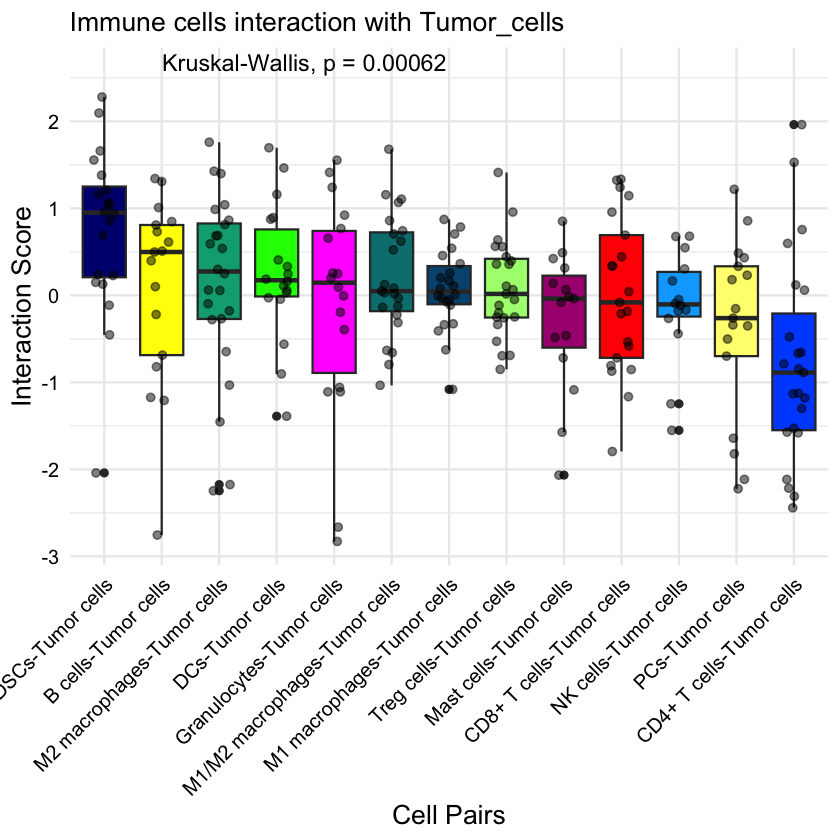

In [178]:
a

ggsave(
  filename = paste0("~/Desktop/PhD/NMC/results/poster_interaction_boxplot", ".svg"),
  plot = a,
  width = 11,
  height = 6,
  dpi = 300,
)

In [207]:
distances_ht <- read.csv(file.path(dir, "distances_to_tumor_cells_by_patient.csv"))
distances_ht[distances_ht == ""] <- NA
distances_ht <- distances_ht %>%
    group_by(cell_category, patient_exp) %>%
    summarise(median_distance = median(as.numeric(Tumor.cells), na.rm = TRUE))

`summarise()` has grouped output by 'cell_category'. You can override using the
`.groups` argument.


In [208]:
#make cells_split factors
cells_split <- c("Myeloid", "Myeloid", "Myeloid", "Myeloid", "Myeloid", "Myeloid", "Myeloid", "Lymphoid", "Lymphoid", "Lymphoid", "Lymphoid", "Lymphoid", "Lymphoid")

cells_split <- factor(cells_split, levels = c("Myeloid", "Lymphoid"))

cell_types <- c(
  "MDSCs", "M2 macrophages", "M1 macrophages", "M1/M2 macrophages",
  "Granulocytes", "Mast cells", "DCs", "B cells", "PCs", "NK cells",
  "Treg T cells", "CD4+ T cells", "CD8+ T cells")

In [215]:
minmax_col <- function(x) (x - min(x, na.rm = TRUE)) / (max(x, na.rm = TRUE) - min(x, na.rm = TRUE))

distances_ht_final <- distances_ht %>%
  filter(!cell_category %in% c("Epithelial cells", "Tumor cells", "Lymphatic endothelial cells", "Endothelial cells", "NFC", "Actin+ cells")) %>%
  pivot_wider(names_from = "patient_exp", values_from = "median_distance") %>%
  arrange(factor(cell_category, levels = cell_types)) %>%
  column_to_rownames(var = "cell_category") %>%
  as.matrix()

distances_ht_final <- apply(distances_ht_final, 2, minmax_col)

In [217]:
#arrange column in alphabetical order
columns_order <- c(
  "NMC_1_ROI1", "NMC_1_ROI3", "NMC_2_ROI1", "NMC_4_ROI9",
  "NMC_5_ROI10", "NMC_5_ROI11", "NMC_6_ROI5", "NMC_6_ROI6",
  "NMC_7_ROI13", "NMC_7_ROI14", "NMC_8_ROI17", "NMC_9_ROI3",
  "NMC_9_ROI4", "NMC_12_ROI5", "NMC_12_ROI6", "NMC_13_ROI14",
  "NMC_13_ROI15", "NMC_14_ROI8", "NMC_14_ROI11", "NMC_15_ROI7",
  "NMC_15_ROI16", "NMC_16_ROI17", "NMC_16_ROI19", "NMC_21_ROI23"
)

distances_ht_final <- distances_ht_final[, columns_order]
distances_ht_final

,NMC_1_ROI1,NMC_1_ROI3,NMC_2_ROI1,NMC_4_ROI9,NMC_5_ROI10,NMC_5_ROI11,NMC_6_ROI5,NMC_6_ROI6,NMC_7_ROI13,NMC_7_ROI14,...,NMC_12_ROI6,NMC_13_ROI14,NMC_13_ROI15,NMC_14_ROI8,NMC_14_ROI11,NMC_15_ROI7,NMC_15_ROI16,NMC_16_ROI17,NMC_16_ROI19,NMC_21_ROI23
MDSCs,0.07700612,0.10325162,0.32084007,0.00996036,0.2655379,0.01146857,NA,NA,0.08623842,0.04665372,...,0.117307822,0.007240317,0.008963091,0.054974447,0.02008359,0.5374289,0.93375506,0.00000000,0.04486447,NA
M2 macrophages,0.05562291,0.13378305,0.05441717,0.02541684,0.1402925,0.12439727,0.000000000,0.11203546,0.08951066,0.07412068,...,0.000000000,0.047862404,0.023253839,0.128786134,0.31424769,0.2989100,0.62064077,0.03820633,0.05101918,0.6383402
M1 macrophages,0.09745486,0.18501627,0.26706647,0.02485593,0.4381139,0.00000000,0.008234463,0.08417830,0.36098268,0.10100708,...,0.138608117,0.033905536,0.092578569,0.870996651,0.09654122,0.4508163,0.39314378,0.05098187,0.06459734,0.2207229
M1/M2 macrophages,0.09215686,0.09657193,0.20515196,1.00000000,0.1146806,0.27577332,0.068271976,0.19313297,0.33559916,0.14302997,...,0.080157880,0.065242583,0.566469373,0.128494243,0.00000000,0.0000000,0.23537658,0.24139464,0.07220385,0.4265086
Granulocytes,0.21718717,1.00000000,0.42006163,0.01148792,0.4120646,0.90875512,1.000000000,0.03908107,1.00000000,1.00000000,...,0.007387438,0.000000000,0.047020460,0.611310502,0.31034969,0.5862575,0.43277405,0.01250708,0.06722072,1.0000000
Mast cells,0.07647727,0.34310653,0.12454470,0.19896300,0.4715632,0.25802096,0.929263932,1.00000000,0.80071072,0.62050057,...,0.257032827,1.000000000,0.483688511,1.000000000,0.40656597,1.0000000,0.75714855,0.26568953,0.03113644,0.6831620
DCs,1.00000000,0.00000000,0.82541649,0.00000000,0.0000000,0.37444231,0.577011980,0.00000000,0.00000000,0.00000000,...,0.147214799,0.298616378,0.007606289,0.008189701,1.00000000,NA,NA,1.00000000,0.08311157,0.4863764
B cells,0.12910287,0.05336978,0.00000000,NA,0.3191142,0.50711414,0.813319552,0.48933995,0.05889317,0.12249766,...,1.000000000,0.003235008,0.000000000,0.689296594,0.01389742,0.6074808,0.42681422,0.80435596,0.31564624,0.0000000
PCs,0.26655652,0.31811964,NA,0.07446739,0.5131212,NA,0.756182216,0.61997290,NA,NA,...,0.406603286,0.265256982,0.482623796,0.070056733,0.30285447,0.6643504,0.90775002,0.31759947,0.14298420,NA
NK cells,0.05971984,0.16984126,1.00000000,0.38784784,0.4301601,0.40715648,0.393567544,0.11817721,0.94406830,0.32750224,...,0.576045911,0.006793094,0.005573131,0.000000000,NA,0.6229256,1.00000000,0.48862050,1.00000000,0.1147591


In [218]:
main_col_fun = colorRamp2(
  c(0,0.5,1), 
  c("#8a22ff", "#fdc5ea","#f7f7f7"))


ht = Heatmap(distances_ht_final,
        column_names_rot = 45,
        col = main_col_fun,
        row_split = cells_split,
        border = TRUE,
        heatmap_legend_param = list(
            title = "Scaled distance",   # change legend title
            title_gp = gpar(fontsize = 16), # title font
            labels_gp = gpar(fontsize = 13), # tick labels font
            legend_height = unit(3, "cm"),   # make legend bar taller
            legend_width  = unit(3, "cm")),
        cluster_rows  = FALSE,
        cluster_columns = FALSE,
        column_title = "Average Euclidean distance to Tumor cells by sample",
        row_title = "Cell type",
        row_names_side = "left",
        column_names_gp = gpar(fontsize = 13),
        row_names_gp = gpar(fontsize = 13),
        column_title_gp = gpar(fontsize = 20),
        row_title_gp = gpar(fontsize = 20)
)
ht


In [221]:
library(svglite)
svglite("~/Desktop/PhD/NMC/results/heatmap_distances.svg", width = 12, height = 6)  # adjust size
draw(ht, heatmap_legend_side = "right")
dev.off()

agg_record_1953447608 
                    2